# 🛠️ Project 2: Operations Support SLA & CSAT Root Cause Analysis
**Business Domain:** Customer Operations & Service Level Agreements (SLA)  
**Objective:** Audit support ticket resolution rates, identify category bottlenecks, and quantify the correlation between SLA breaches and Customer Satisfaction (CSAT) score drops.

### Business Context
Support operations has seen a recent increase in negative customer feedback. The Operations team needs to:
1. Measure **SLA compliance** across all ticket categories.
2. Identify which ticket categories cause the most **SLA breaches** (Pareto principle).
3. Quantify how **breaching SLAs** hurts customer sentiment (CSAT scores).
4. Provide process recommendations to resolve bottlenecks.

---

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Style config
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    "font.size": 10,
    "figure.figsize": (8, 4.5),
    "axes.edgecolor": "#CBD5E1",
    "axes.facecolor": "#FAFAFA"
})

ACCENT = "#2563EB"
ALERT = "#EA580C"
DARK = "#1E293B"
MUTED = "#64748B"


In [2]:
# Load raw simulated tickets data
df = pd.read_csv("tickets.csv")

# Parse dates and numeric columns
df['created_at'] = pd.to_datetime(df['created_at'])
df['resolved_at'] = pd.to_datetime(df['resolved_at'])
df['handling_time_hours'] = pd.to_numeric(df['handling_time_hours'], errors='coerce')
df['customer_satisfaction'] = pd.to_numeric(df['customer_satisfaction'], errors='coerce')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1000, 10)


,ticket_id,created_at,resolved_at,status,priority,category,sla_hours,handling_time_hours,is_breach,customer_satisfaction
0,20001,2026-04-18 08:54:58,NaT,Open,Low,Billing,24,NaN,0,NaN
1,20002,2026-04-07 19:51:22,NaT,Open,Low,Technical Support,48,NaN,0,NaN
2,20003,2026-04-03 01:05:05,2026-04-03 05:39:53,Resolved,High,Billing,24,4.58,0,4.0
3,20004,2026-05-15 19:50:26,NaT,Open,High,Technical Support,48,NaN,0,NaN
4,20005,2026-05-08 10:07:43,2026-05-16 07:59:19,Resolved,Low,Delivery Issue,72,189.86,1,1.0


## 📊 Part 1: Overall SLA Compliance Metrics
Let's calculate the total volume, resolution rate, and SLA compliance rate.

In [3]:
total_tickets = len(df)
resolved_df = df[df['status'].isin(['Resolved', 'Closed'])]
resolved_count = len(resolved_df)
breached_count = resolved_df['is_breach'].sum()
sla_compliance = ((resolved_count - breached_count) / resolved_count) * 100

print(f"Total Tickets: {total_tickets}")
print(f"Resolved Tickets: {resolved_count} ({resolved_count/total_tickets:.1%})")
print(f"SLA Compliance Rate: {sla_compliance:.2f}%")

Total Tickets: 1000
Resolved Tickets: 688 (68.8%)
SLA Compliance Rate: 80.67%


## 🔍 Part 2: Category Breakdown & Bottleneck Identification
Let's see which support categories are failing their SLA commitments.

In [4]:
cat_df = resolved_df.groupby('category').agg(
    volume=('ticket_id', 'count'),
    avg_handling_time=('handling_time_hours', 'mean'),
    sla_target=('sla_hours', 'first'),
    breach_count=('is_breach', 'sum'),
    avg_csat=('customer_satisfaction', 'mean')
).reset_index()

cat_df['breach_rate_pct'] = (cat_df['breach_count'] / cat_df['volume']) * 100
cat_df.sort_values(by='breach_rate_pct', ascending=False)

,category,volume,avg_handling_time,sla_target,breach_count,avg_csat,breach_rate_pct
2,Delivery Issue,162,71.334444,72,66,2.123457,40.740741
3,Technical Support,170,34.662176,48,47,3.194118,27.647059
1,Billing,173,12.331734,24,12,4.098266,6.936416
0,Account Access,183,5.736175,12,8,4.409836,4.371585


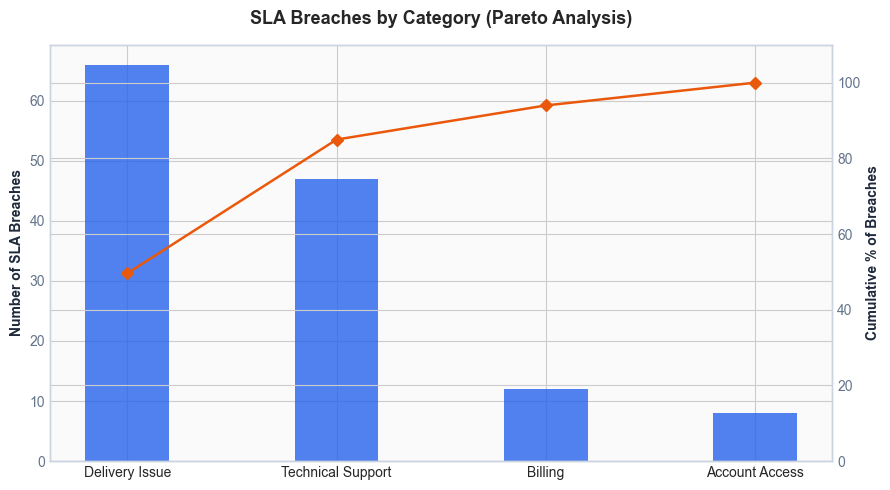

In [5]:
# Pareto Analysis of SLA Breaches
pareto_data = cat_df.sort_values(by='breach_count', ascending=False)
pareto_data['cumulative_pct'] = (pareto_data['breach_count'].cumsum() / pareto_data['breach_count'].sum()) * 100

fig, ax1 = plt.subplots(figsize=(9, 5))
bars = ax1.bar(pareto_data['category'], pareto_data['breach_count'], color=ACCENT, alpha=0.8, width=0.4)
ax1.set_ylabel('Number of SLA Breaches', color=DARK, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=MUTED)

ax2 = ax1.twinx()
ax2.plot(pareto_data['category'], pareto_data['cumulative_pct'], color=ALERT, marker='D', ms=6, linewidth=1.8)
ax2.set_ylabel('Cumulative % of Breaches', color=DARK, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=MUTED)
ax2.set_ylim(0, 110)

plt.title('SLA Breaches by Category (Pareto Analysis)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 🗣️ Part 3: CSAT Impact Quantification
Let's analyze customer satisfaction (CSAT) scores when SLAs are met vs when they are breached.

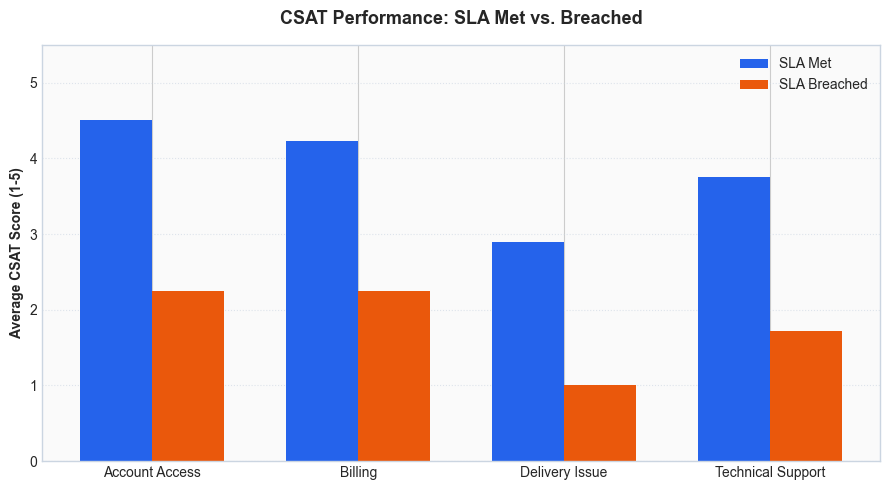

In [6]:
# Grouped bar chart comparing CSAT
csat_groups = resolved_df.groupby(['category', 'is_breach'])['customer_satisfaction'].mean().unstack().reset_index()
csat_groups.columns = ['Category', 'SLA Met', 'SLA Breached']

x_positions = range(len(csat_groups))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar([x - width/2 for x in x_positions], csat_groups['SLA Met'], width, label='SLA Met', color=ACCENT)
plt.bar([x + width/2 for x in x_positions], csat_groups['SLA Breached'], width, label='SLA Breached', color=ALERT)

plt.xticks(x_positions, csat_groups['Category'])
plt.ylabel('Average CSAT Score (1-5)', fontweight='bold')
plt.title('CSAT Performance: SLA Met vs. Breached', fontsize=13, fontweight='bold', pad=15)
plt.ylim(0, 5.5)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.6, color='#CBD5E1')
plt.tight_layout()
plt.show()

## 💡 Part 4: Root Cause & Process Recommendations
Based on the analysis, here is our operational action plan:
1. **Target Delivery Issues:** **Delivery Issues** are our primary bottleneck, with a high breach rate. The average handling time exceeds the target.
2. **Quantify CSAT Impact:** Tickets that breach SLA drop dramatically in CSAT, showing a significant drop in customer satisfaction compared to tickets met within SLA.
3. **Escalation Rules:** Implement real-time alerts in Salesforce/CRM when 'Delivery Issue' or 'Technical Support' tickets reach 50% of SLA thresholds.
